In [ ]:
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler

CB_COLORS = ["#0C7BDC", "#FFC20A", "#009E73", "#CC79A7", "#D55E00"] #colorblindness friendly colors
mpl.rcParams['axes.prop_cycle'] = cycler(*CB_COLORS) 

# Cross Validation Results (Preliminary Plots)

## Model Validation

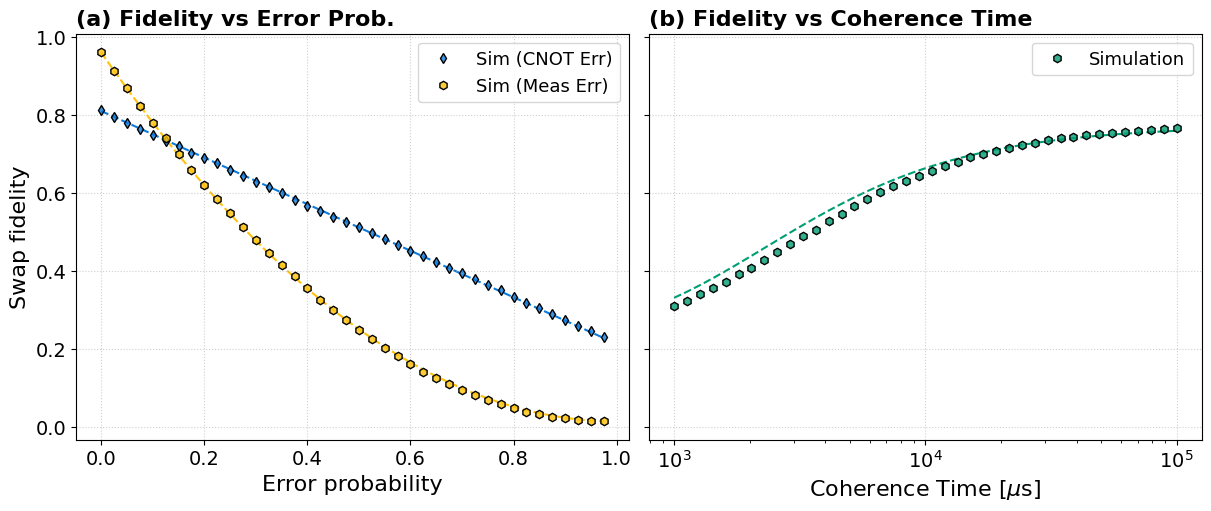

In [22]:
def experiemnt_0_plot(show_error_bars=False, colors=None, marker_alpha=0.5):
    """
    Plots Experiment 0 data.
    
    Args:
        show_error_bars (bool): Toggle for rendering standard deviation error bars.
        colors (list): List of color strings. Uses DEFAULT_CB_COLORS if None.
                       Requires at least 3 colors (CNOT, Meas, Coherence).
        marker_alpha (float): Opacity of the marker fill (0.0 to 1.0).
    """
    # Use default palette if none is provided
    if colors is None:
        colors = CB_COLORS
        
    # Attempt to load the dataset
    try:
        df = pd.read_csv('exp0.csv')
    except FileNotFoundError:
        print("Error: 'exp0.csv' not found. Please provide data or modify code.")
        return

    # Filter for the specific scenario
    df_filtered = df[df['num_bellpairs'] == 10_000]

    if df_filtered.empty:
        print("Error: No data remains after filtering num_bellpairs == 10_000.")
        return

    # Dataset 1: Varying CNOT Error (Measurement error fixed at 0.1, CT=0)
    df_cnot_sweep = df_filtered[(df_filtered['meas_err_prob'] == 0.1) & 
                                (df_filtered['coherence_time'] == 0)]
    
    # Dataset 2: Varying Measurement Error (CNOT error fixed at 0.05, CT=0)
    df_meas_sweep = df_filtered[(df_filtered['cnot_err_prob'] == 0.05) & 
                                (df_filtered['coherence_time'] == 0)]

    # Dataset 3: Varying Coherence Time (Meas=0.1, CNOT=0.05)
    df_coherence_sweep = df_filtered[(df_filtered['meas_err_prob'] == 0.1) & 
                                    (df_filtered['cnot_err_prob'] == 0.05) &
                                    (df_filtered['coherence_time'] > 1)]
    coherence_times = df_coherence_sweep['coherence_time']


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True, layout="constrained")

    # ==========================================
    # Define Plot Colors & Fills Dynamically
    # ==========================================
    # Extract solids from the passed list and apply the passed alpha parameter
    cnot_solid = colors[0] 
    cnot_fill  = mcolors.to_rgba(cnot_solid, alpha=marker_alpha)
    
    meas_solid = colors[1] 
    meas_fill  = mcolors.to_rgba(meas_solid, alpha=marker_alpha)
    
    coh_solid  = colors[2] 
    coh_fill   = mcolors.to_rgba(coh_solid, alpha=marker_alpha)

    # ==========================================
    # Error Bar Toggle Logic
    # ==========================================
    yerr_cnot = df_cnot_sweep['fidelity_std'] if show_error_bars else None
    yerr_meas = df_meas_sweep['fidelity_std'] if show_error_bars else None
    yerr_coh  = df_coherence_sweep['fidelity_std'] if show_error_bars else None
    
    cap_size = 4 if show_error_bars else 0

    # ==========================================
    # --- Left Plot (ax1): Fidelity vs Error Probabilities ---
    # ==========================================

    # 1. Plot Analytical lines FIRST (zorder=1)
    if not df_cnot_sweep.empty:
        ax1.plot(df_cnot_sweep['cnot_err_prob'], df_cnot_sweep['fidelity_analytical'], 
                 linestyle='--', color=cnot_solid, linewidth=1.5, zorder=1)

    if not df_meas_sweep.empty:
        ax1.plot(df_meas_sweep['meas_err_prob'], df_meas_sweep['fidelity_analytical'], 
                 linestyle='--', color=meas_solid, linewidth=1.5, zorder=1)

    # 2. Plot Simulation data points (and optional error bars)
    if not df_cnot_sweep.empty:
        ax1.errorbar(df_cnot_sweep['cnot_err_prob'], df_cnot_sweep['fidelity_mean'], 
                     yerr=yerr_cnot, 
                     fmt='d', markersize=5, color='black', 
                     markerfacecolor=cnot_fill, 
                     markeredgecolor='black', 
                     capsize=cap_size, zorder=2, label='Sim (CNOT Err)')
                     
    if not df_meas_sweep.empty:
        ax1.errorbar(df_meas_sweep['meas_err_prob'], df_meas_sweep['fidelity_mean'], 
                     yerr=yerr_meas, 
                     fmt='h', markersize=6, color='black', 
                     markerfacecolor=meas_fill, 
                     markeredgecolor='black', 
                     capsize=cap_size, zorder=2, label='Sim (Meas Err)')

    ax1.set_xlabel('Error probability', fontsize=16)
    ax1.set_ylabel('Swap fidelity', fontsize=16)
    ax1.set_title('(a) Fidelity vs Error Prob.', loc="left", fontsize=16, weight="bold")
    ax1.tick_params(axis="both", labelsize=14)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(fontsize=13)

    # ==========================================
    # --- Right Plot (ax2): Fidelity vs Coherence Time ---
    # ==========================================

    if not df_coherence_sweep.empty:
        ax2.plot(coherence_times, df_coherence_sweep['fidelity_analytical'], 
                 linestyle='--', color=coh_solid, linewidth=1.5, zorder=1)

        ax2.errorbar(coherence_times, df_coherence_sweep['fidelity_mean'], 
                     yerr=yerr_coh, 
                     fmt='h', markersize=6, color='black',
                     markerfacecolor=coh_fill, 
                     markeredgecolor='black', 
                     capsize=cap_size, zorder=2, label='Simulation')

    ax2.set_xlabel(r'Coherence Time [$\mu$s]', fontsize=16)
    ax2.set_xscale('log')       
    ax2.set_title('(b) Fidelity vs Coherence Time', loc="left", fontsize=16, weight="bold")
    ax2.tick_params(axis="both", labelsize=14)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(fontsize=13)

    plt.show()

# Example usage with custom parameters:
# experiemnt_0_plot(show_error_bars=False, colors=["red", "blue", "green"], marker_alpha=0.3)
experiemnt_0_plot(show_error_bars=False, marker_alpha=0.8)

## Experiment 1: Symmetric MIM Link with varying quantum memories

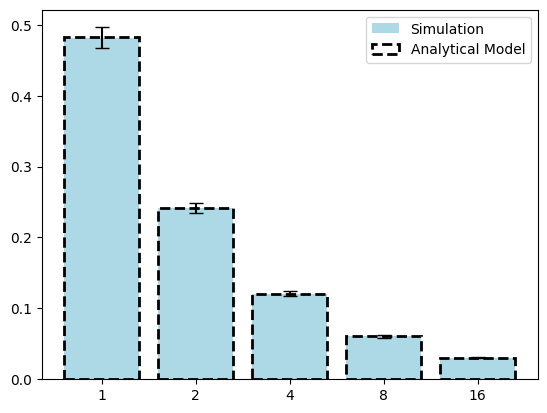

In [3]:
def experiemnt_1_plot():
    df = pd.read_csv('exp1.csv')
    df = df[df['num_mem'] < 32]

    xs = [str(x) for x in df['num_mem']]

    time_sim = df['completion_time_mean']
    time_std = df['completion_time_std']
    time_ana = df['completion_time_analytical']


    plt.bar(xs, time_sim, yerr=time_std, capsize=5, label='Simulation', color='lightblue')
    # add dotted border for analytical model
    plt.bar(xs, time_ana, fill=False, edgecolor='black', linestyle='--', linewidth=2, label='Analytical Model')

    plt.legend()
    plt.show()
experiemnt_1_plot()

## Experiment 2: Assymetric MIM Link Varying BSA Placement with a Single Memory 

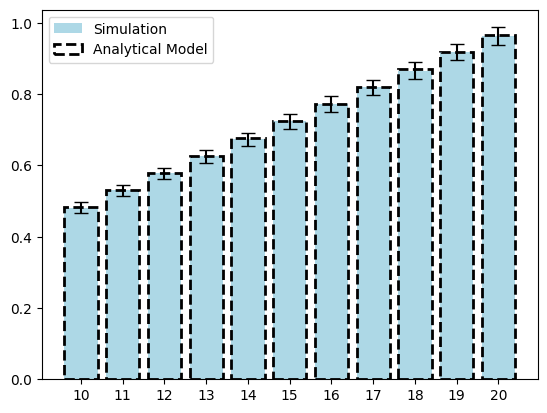

In [4]:
def experiemnt_2_plot():
    df = pd.read_csv('exp2.csv')
    # df = df[df['num_mem'] < 32]

    xs = [str(x) for x in df['alice_dist']]
    time_sim = df['completion_time_mean']
    time_std = df['completion_time_std']
    time_ana = df['completion_time_analytical']

    plt.bar(xs, time_sim, yerr=time_std, capsize=5, label='Simulation', color='lightblue')
    # add dotted border for analytical model
    plt.bar(xs, time_ana, fill=False, edgecolor='black', linestyle='--', linewidth=2, label='Analytical Model')

    plt.legend()
    plt.show()
experiemnt_2_plot()

# Experiment 3: Entanglement Swapping: seeing the errors

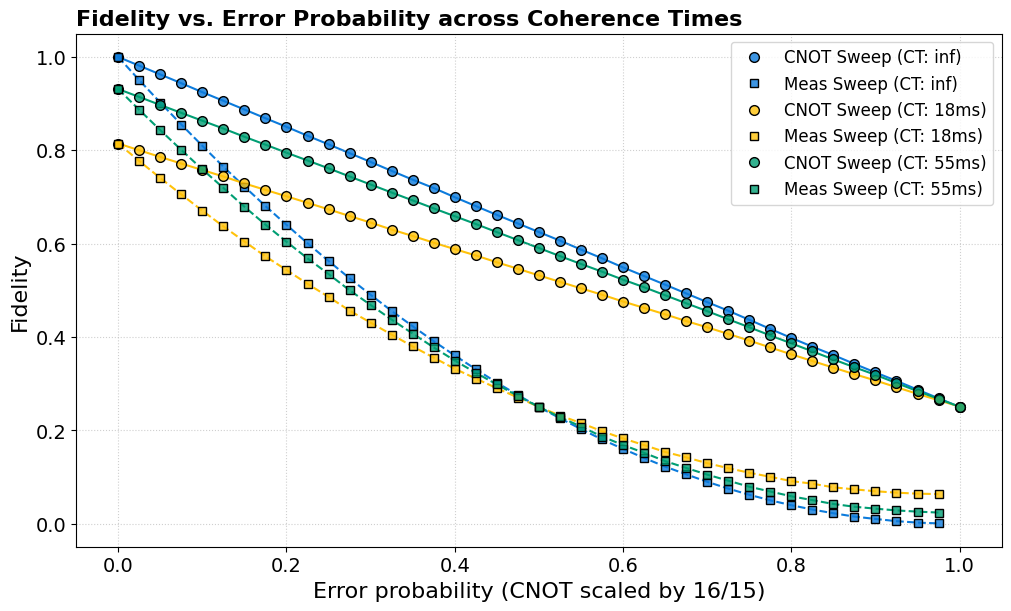

In [25]:
def experiemnt_3_plot(show_error_bars=False, colors=None, marker_alpha=0.5):
    """
    Plots Experiment 3 data.
    
    Args:
        show_error_bars (bool): Toggle for rendering standard deviation error bars.
        colors (list): List of color strings. Uses DEFAULT_CB_COLORS if None.
                       Requires at least 3 colors for the 3 coherence times.
        marker_alpha (float): Opacity of the marker fill (0.0 to 1.0).
    """
    if colors is None:
        colors = CB_COLORS
        
    try:
        df = pd.read_csv('exp3.csv')
    except FileNotFoundError:
        print("Error: 'exp3.csv' not found. Please provide data or modify code.")
        return

    df = df[df['num_bellpairs'] == 100_000]

    coherence_times = sorted(df['coherence_time'].unique())

    ct_map = {
        0: 'inf', 
        9728: '18ms', 
        29723: '55ms'
    }

    # Using layout="constrained" and similar proportions to your other plots
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

    # Filter out the individual sweeps
    df_cnot_sweep = df[df['meas_err_prob'] == 0.0]
    df_meas_sweep = df[df['cnot_err_prob'] == 0.0]

    # Global error bar toggle
    cap_size = 4 if show_error_bars else 0

    for i, ct in enumerate(coherence_times):
        # Dynamically assign colors based on the loop index
        solid_color = colors[i % len(colors)]
        fill_color  = mcolors.to_rgba(solid_color, alpha=marker_alpha)
        ct_label    = ct_map.get(ct, str(ct))

        # ==========================================
        # 1. Plot CNOT Sweep (Solid lines, Circle 'o' markers)
        # ==========================================
        df_ct_cnot = df_cnot_sweep[df_cnot_sweep['coherence_time'] == ct]
        if not df_ct_cnot.empty:
            x_cnot = df_ct_cnot['cnot_err_prob'] * (16 / 15)
            yerr_cnot = df_ct_cnot['fidelity_std'] if show_error_bars else None
            
            # Line (zorder=1 pushes it behind the markers)
            ax.plot(x_cnot, df_ct_cnot['fidelity_mean'], 
                    linestyle='-', color=solid_color, linewidth=1.5, zorder=1)
            
            # Markers & Error bars
            ax.errorbar(x_cnot, df_ct_cnot['fidelity_mean'], yerr=yerr_cnot, 
                        fmt='o', markersize=7, color='black', 
                        markerfacecolor=fill_color, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label=f'CNOT Sweep (CT: {ct_label})')

        # ==========================================
        # 2. Plot Measurement Sweep (Dashed lines, Square 's' markers)
        # ==========================================
        df_ct_meas = df_meas_sweep[df_meas_sweep['coherence_time'] == ct]
        if not df_ct_meas.empty:
            x_meas = df_ct_meas['meas_err_prob']
            yerr_meas = df_ct_meas['fidelity_std'] if show_error_bars else None
            
            # Line (zorder=1)
            ax.plot(x_meas, df_ct_meas['fidelity_mean'], 
                    linestyle='--', color=solid_color, linewidth=1.5, zorder=1)
            
            # Markers & Error bars
            ax.errorbar(x_meas, df_ct_meas['fidelity_mean'], yerr=yerr_meas, 
                        fmt='s', markersize=6, color='black', 
                        markerfacecolor=fill_color, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label=f'Meas Sweep (CT: {ct_label})')

    # ==========================================
    # Formatting and Display
    # ==========================================
    ax.set_xlabel('Error probability (CNOT scaled by 16/15)', fontsize=16)
    ax.set_ylabel('Fidelity', fontsize=16)
    ax.set_title('Fidelity vs. Error Probability across Coherence Times', loc="left", fontsize=16, weight="bold")
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Place the legend outside or scale it appropriately if it overlaps with data
    ax.legend(fontsize=12) 

    plt.show()

# Run the plot WITHOUT error bars as default
experiemnt_3_plot(show_error_bars=False, marker_alpha=0.8)

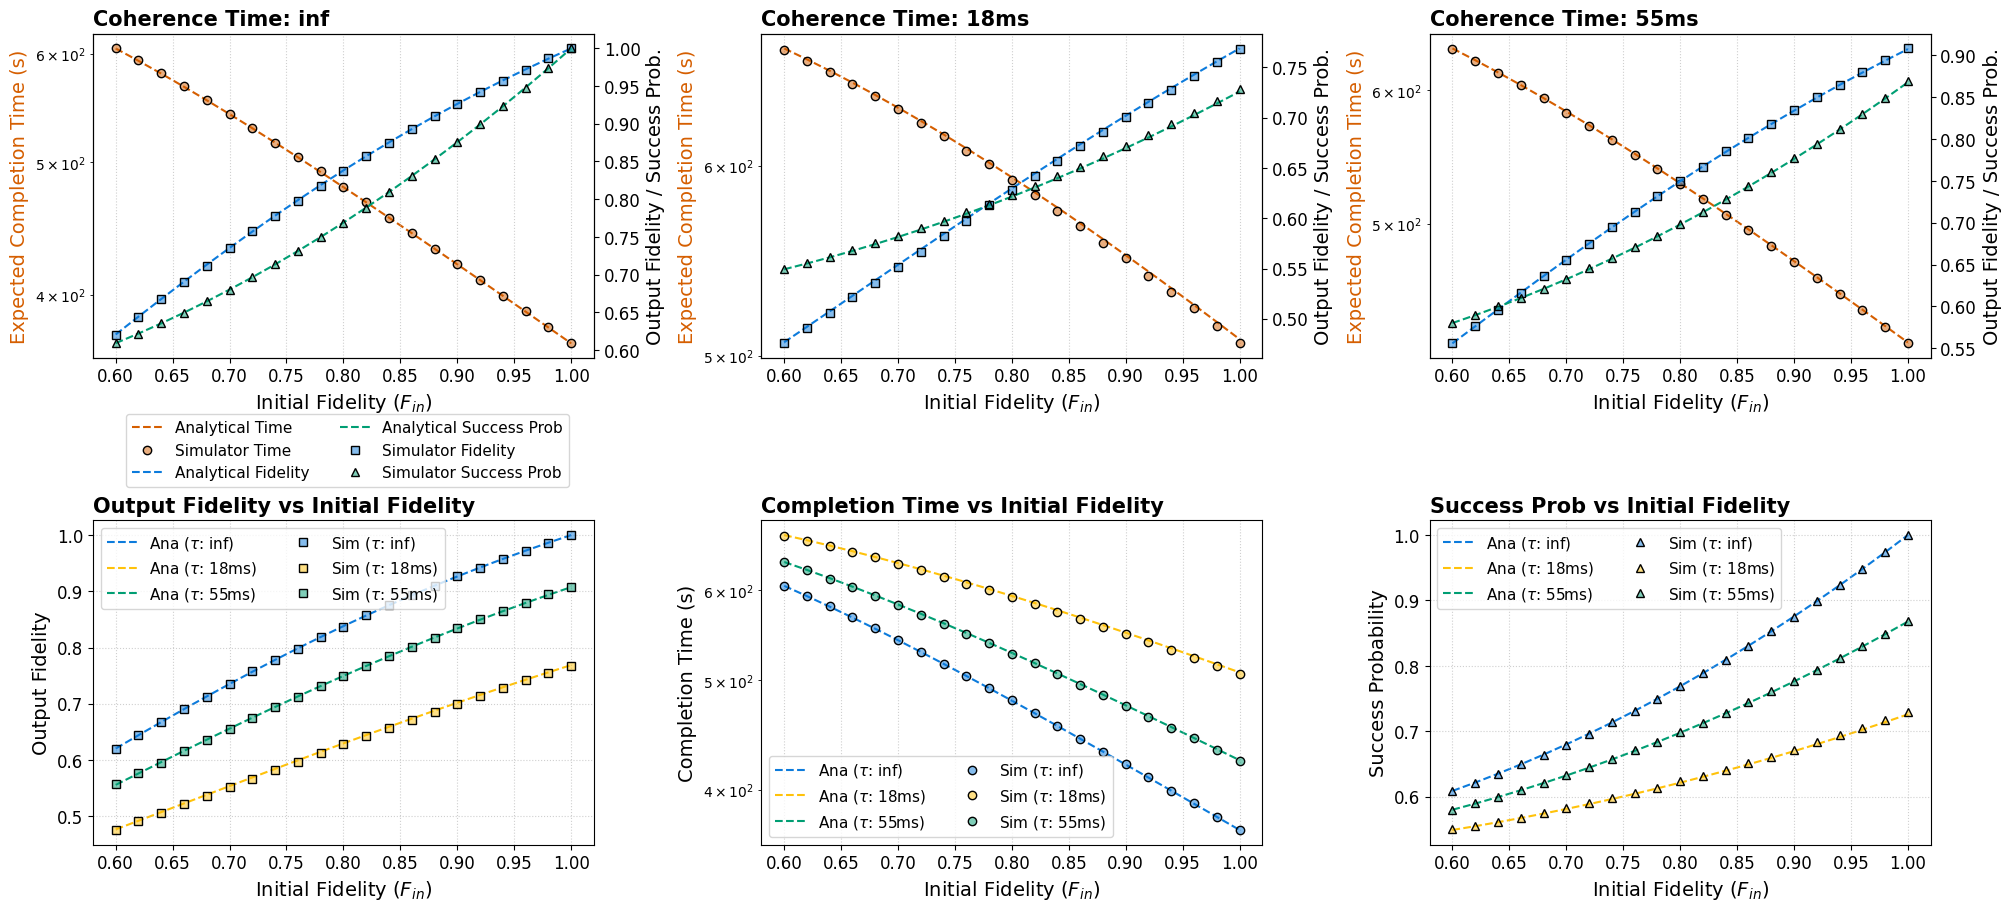

In [28]:
def experiment_4_plot(show_error_bars=False, colors=None, marker_alpha=0.5):
    """
    Plots Experiment 4 data in a 2x3 grid.
    
    Args:
        show_error_bars (bool): Toggle for rendering standard deviation error bars.
        colors (list): List of color strings. Uses DEFAULT_CB_COLORS if None.
        marker_alpha (float): Opacity of the marker fill (0.0 to 1.0).
    """
    if colors is None:
        colors = CB_COLORS

    try:
        df = pd.read_csv('exp4.csv')
    except FileNotFoundError:
        print("Error: 'exp4.csv' not found. Please provide data or modify code.")
        return

    df = df[df['num_bellpairs'] == 100_000]
    df = df[(df['link_fidelity'] >= 0.6) & (df['link_fidelity'] <= 1.0)]

    # Maps and lists to keep loops organized
    ct_map = {0: 'inf', 9728: '18ms', 29723: '55ms'}
    coherence_times = [0, 9728, 29723]
    
    # Global error bar toggle
    cap_size = 3 if show_error_bars else 0

    # Create a 2x3 grid of subplots (Wider and Shorter: 20x9)
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 9), layout="constrained")

    # ==========================================
    # ROW 1: Replicating the image for each Coherence Time
    # ==========================================
    # Define Metric Colors for Row 1
    c_time_solid = colors[4] # Vermillion for Time
    c_time_fill  = mcolors.to_rgba(c_time_solid, alpha=marker_alpha)
    
    c_fid_solid  = colors[0] # Blue for Fidelity
    c_fid_fill   = mcolors.to_rgba(c_fid_solid, alpha=marker_alpha)
    
    c_suc_solid  = colors[2] # Green for Success Prob
    c_suc_fill   = mcolors.to_rgba(c_suc_solid, alpha=marker_alpha)

    for i, ct in enumerate(coherence_times):
        df_ct = df[df['coherence_time'] == ct].sort_values('link_fidelity')
        if df_ct.empty: continue
            
        x = df_ct['link_fidelity']
        ax_left = axes[0, i]
        ax_right = ax_left.twinx() 
        
        # 1. Completion Time (Left Y-Axis, Log Scale)
        yerr_time = df_ct['completion_time_std'] if show_error_bars else None
        ax_left.plot(x, df_ct['completion_time_analytical'], linestyle='--', color=c_time_solid, linewidth=1.5, zorder=1, label='Analytical Time')
        ax_left.errorbar(x, df_ct['completion_time_mean'], yerr=yerr_time, 
                        fmt='o', markersize=6, color='black', markerfacecolor=c_time_fill, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label='Simulator Time')
        ax_left.set_yscale('log')
        
        # 2. Fidelity (Right Y-Axis)
        yerr_fid = df_ct['fidelity_std'] if show_error_bars else None
        ax_right.plot(x, df_ct['fidelity_analytical'], linestyle='--', color=c_fid_solid, linewidth=1.5, zorder=1, label='Analytical Fidelity')
        ax_right.errorbar(x, df_ct['fidelity_mean'], yerr=yerr_fid, 
                        fmt='s', markersize=6, color='black', markerfacecolor=c_fid_fill, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label='Simulator Fidelity')
        
        # 3. Success Probability (Right Y-Axis)
        yerr_suc = df_ct['purification_success_prob_std'] if show_error_bars else None
        ax_right.plot(x, df_ct['purification_success_prob_analytical'], linestyle='--', color=c_suc_solid, linewidth=1.5, zorder=1, label='Analytical Success Prob')
        ax_right.errorbar(x, df_ct['purification_success_prob_mean'], yerr=yerr_suc, 
                        fmt='^', markersize=6, color='black', markerfacecolor=c_suc_fill, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label='Simulator Success Prob')
        
        # Formatting for Row 1
        ax_left.set_title(f'Coherence Time: {ct_map[ct]}', loc="left", fontsize=15, weight="bold")
        ax_left.set_xlabel('Initial Fidelity ($F_{in}$)', fontsize=14)
        ax_left.set_ylabel('Expected Completion Time (s)', color=c_time_solid, fontsize=14)
        ax_right.set_ylabel('Output Fidelity / Success Prob.', color='black', fontsize=14)
        
        ax_left.tick_params(axis='y', colors=c_time_solid, labelsize=12)
        ax_left.tick_params(axis='x', labelsize=12)
        ax_right.tick_params(axis='y', labelsize=12)
        ax_left.grid(True, linestyle=':', alpha=0.6)
        ax_left.set_xlim(0.58, 1.02)
        
        # Unified legend to the first plot only
        if i == 0:
            lines1, labels1 = ax_left.get_legend_handles_labels()
            lines2, labels2 = ax_right.get_legend_handles_labels()
            ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
                        bbox_to_anchor=(0.05, -0.15), ncol=2, fontsize=11)

    # ==========================================
    # ROW 2: Overlaying Coherence Times for each Metric
    # ==========================================
    ax_fid = axes[1, 0]
    ax_time = axes[1, 1]
    ax_succ = axes[1, 2]

    for i, ct in enumerate(coherence_times):
        df_ct = df[df['coherence_time'] == ct].sort_values('link_fidelity')
        if df_ct.empty: continue
            
        x = df_ct['link_fidelity']
        label_sim = f'Sim ($\\tau$: {ct_map[ct]})'
        label_ana = f'Ana ($\\tau$: {ct_map[ct]})'
        
        # Differentiating Coherence times by mapping them to the first 3 colors in the palette
        solid_color = colors[i] 
        fill_color  = mcolors.to_rgba(solid_color, alpha=marker_alpha)
        
        # Subplot 1: Fidelity
        yerr_fid = df_ct['fidelity_std'] if show_error_bars else None
        ax_fid.plot(x, df_ct['fidelity_analytical'], linestyle='--', color=solid_color, linewidth=1.5, zorder=1, label=label_ana)
        ax_fid.errorbar(x, df_ct['fidelity_mean'], yerr=yerr_fid, 
                        fmt='s', markersize=6, color='black', markerfacecolor=fill_color, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label=label_sim)
        
        # Subplot 2: Completion Time
        yerr_time = df_ct['completion_time_std'] if show_error_bars else None
        ax_time.plot(x, df_ct['completion_time_analytical'], linestyle='--', color=solid_color, linewidth=1.5, zorder=1, label=label_ana)
        ax_time.errorbar(x, df_ct['completion_time_mean'], yerr=yerr_time, 
                        fmt='o', markersize=6, color='black', markerfacecolor=fill_color, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label=label_sim)
        
        # Subplot 3: Success Probability
        yerr_suc = df_ct['purification_success_prob_std'] if show_error_bars else None
        ax_succ.plot(x, df_ct['purification_success_prob_analytical'], linestyle='--', color=solid_color, linewidth=1.5, zorder=1, label=label_ana)
        ax_succ.errorbar(x, df_ct['purification_success_prob_mean'], yerr=yerr_suc, 
                        fmt='^', markersize=6, color='black', markerfacecolor=fill_color, markeredgecolor='black', 
                        capsize=cap_size, zorder=2, label=label_sim)

    # Formatting for Row 2
    for ax in [ax_fid, ax_time, ax_succ]:
        ax.set_xlabel('Initial Fidelity ($F_{in}$)', fontsize=14)
        ax.tick_params(axis="both", labelsize=12)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(fontsize=11, ncol=2)
        ax.set_xlim(0.58, 1.02)

    ax_fid.set_title('Output Fidelity vs Initial Fidelity', loc="left", fontsize=15, weight="bold")
    ax_fid.set_ylabel('Output Fidelity', fontsize=14)

    ax_time.set_title('Completion Time vs Initial Fidelity', loc="left", fontsize=15, weight="bold")
    ax_time.set_ylabel('Completion Time (s)', fontsize=14)
    ax_time.set_yscale('log')

    ax_succ.set_title('Success Prob vs Initial Fidelity', loc="left", fontsize=15, weight="bold")
    ax_succ.set_ylabel('Success Probability', fontsize=14)

    plt.show()

# Run the plot WITHOUT error bars
experiment_4_plot(show_error_bars=False)